In [ ]:
# Core libraries
!pip install tensorflow
!pip install tensorflow-datasets

# Data processing
!pip install pillow opencv-python
!pip install pandas numpy matplotlib seaborn plotly

# Model utilities
!pip install scikit-learn

# Deployment (Streamlit only)
!pip install streamlit

# Additional utilities
!pip install tqdm

print("✅ All libraries installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 95.5 MB/s eta 0:00:00
  Attempting uninstall: cachetools
    Found existing installation: cachetools 7.0.1
    Uninstalling cachetools-7.0.1:
      Successfully uninstalled cachetools-7.0.1
✅ All libraries installed successfully!


In [ ]:
# Core imports
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
from tqdm import tqdm
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow_datasets as tfds

# Sklearn utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, mean_absolute_error, mean_squared_error
from sklearn.utils.class_weight import compute_class_weight

# Visualization
import plotly.graph_objects as go
import plotly.express as px

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# GPU configuration
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU available: {len(gpus)} GPU(s)")
    except RuntimeError as e:
        print(e)
else:
    print("No GPU found, using CPU")

# Create directories
os.makedirs('models', exist_ok=True)
os.makedirs('outputs', exist_ok=True)
os.makedirs('logs', exist_ok=True)
os.makedirs('deployment', exist_ok=True)

print("All imports completed successfully!")

No GPU found, using CPU
All imports completed successfully!


In [ ]:
#P1
# Load PlantVillage dataset using TensorFlow Datasets
print("Loading PlantVillage dataset from TensorFlow Datasets...")

# Load dataset with info
dataset, dataset_info = tfds.load(
    'plant_village',
    with_info=True,
    as_supervised=True
)
#dataset
full_dataset = dataset['train']

#datainfo
num_classes = dataset_info.features['label'].num_classes
class_names = dataset_info.features['label'].names

print(f"Dataset loaded successfully!")
print(f"Number of classes: {num_classes}")
print(f"Total original samples: {dataset_info.splits['train'].num_examples}")
print(f"\nFirst 10 classes:")
for i, name in enumerate(class_names[:10]):
    print(f"  {i}: {name}")

Loading PlantVillage dataset from TensorFlow Datasets...


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/plant_village/incomplete.ZOTC1B_1.0.2/plant_village-train.tfrecord*...:   …

Dataset plant_village downloaded and prepared to /root/tensorflow_datasets/plant_village/1.0.2. Subsequent calls will reuse this data.
Dataset loaded successfully!
Number of classes: 38
Total original samples: 54303

First 10 classes:
  0: Apple___Apple_scab
  1: Apple___Black_rot
  2: Apple___Cedar_apple_rust
  3: Apple___healthy
  4: Blueberry___healthy
  5: Cherry___healthy
  6: Cherry___Powdery_mildew
  7: Corn___Cercospora_leaf_spot Gray_leaf_spot
  8: Corn___Common_rust
  9: Corn___healthy


In [ ]:
def limit_dataset_per_class(dataset, class_names, min_samples=100, max_samples=102):
    """
    Limit dataset to have max_samples per class
    """
    print(f"\n Limiting dataset to {min_samples}-{max_samples} images per class...")

    # Collect samples by class
    class_samples = {i: [] for i in range(len(class_names))}

    # Iterate through dataset and collect samples
    for image, label in tqdm(dataset, desc="Collecting samples"):
        label_int = int(label.numpy())
        if len(class_samples[label_int]) < max_samples:
            class_samples[label_int].append((image.numpy(), label_int))

    # Flatten and shuffle
    limited_samples = []
    class_distribution = {}

    for class_idx, samples in class_samples.items():
        # Ensure at least min_samples if available
        num_samples = len(samples)
        class_distribution[class_names[class_idx]] = num_samples
        limited_samples.extend(samples)

    # Shuffle
    np.random.shuffle(limited_samples)

    # Separate images and labels
    images = np.array([s[0] for s in limited_samples])
    labels = np.array([s[1] for s in limited_samples])

    print(f"\nLimited dataset created!")
    print(f"Total samples: {len(labels)}")
    print(f"\nSamples per class (first 10):")
    for i, (class_name, count) in enumerate(list(class_distribution.items())[:10]):
        print(f"  {class_name}: {count}")

    return images, labels, class_distribution

# Limit the dataset
limited_images, limited_labels, class_distribution = limit_dataset_per_class(
    full_dataset,
    class_names,
    min_samples=100,
    max_samples=102
)

print(f"\nFinal dataset shape: {limited_images.shape}")
print(f"Labels shape: {limited_labels.shape}")


🔄 Limiting dataset to 100-102 images per class...



Limited dataset created!
Total samples: 3876

Samples per class (first 10):
  Apple___Apple_scab: 102
  Apple___Black_rot: 102
  Apple___Cedar_apple_rust: 102
  Apple___healthy: 102
  Blueberry___healthy: 102
  Cherry___healthy: 102
  Cherry___Powdery_mildew: 102
  Corn___Cercospora_leaf_spot Gray_leaf_spot: 102
  Corn___Common_rust: 102
  Corn___healthy: 102

Final dataset shape: (3876, 256, 256, 3)
Labels shape: (3876,)


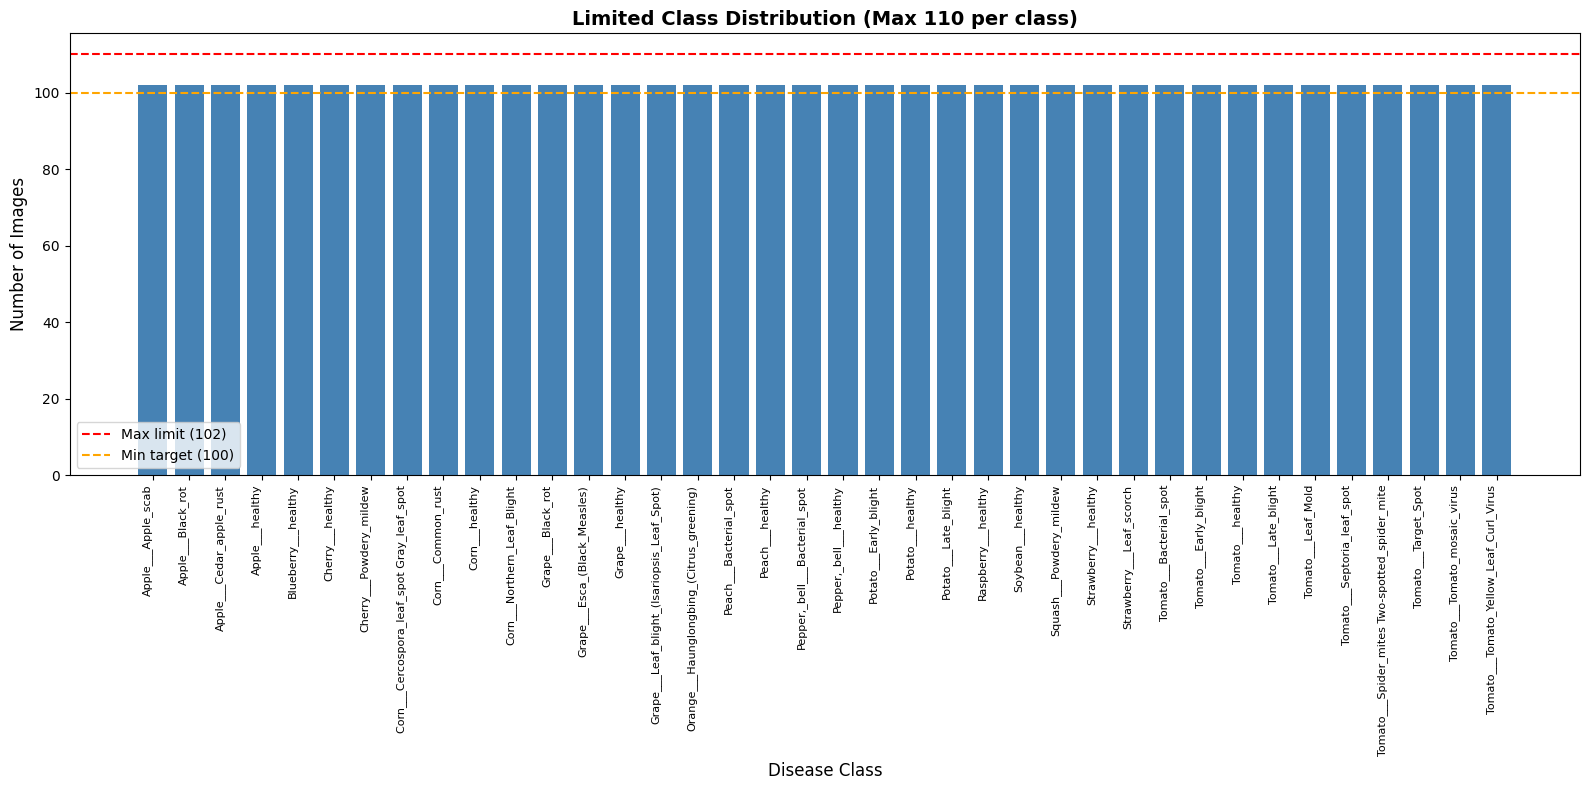


Class distribution statistics:
  Mean: 102.0 images per class
  Std: 0.0
  Min: 102 images
  Max: 102 images


In [ ]:
# Visualize class distribution
def visualize_class_distribution(class_distribution):
    """Visualize the limited class distribution"""

    df = pd.DataFrame(list(class_distribution.items()), columns=['Class', 'Count'])
    df = df.sort_values('Count', ascending=False)

    plt.figure(figsize=(16, 8))
    plt.bar(range(len(df)), df['Count'], color='steelblue')
    plt.xlabel('Disease Class', fontsize=12)
    plt.ylabel('Number of Images', fontsize=12)
    plt.title('Limited Class Distribution (Max 110 per class)', fontsize=14, fontweight='bold')
    plt.xticks(range(len(df)), df['Class'], rotation=90, ha='right', fontsize=8)
    plt.axhline(y=110, color='r', linestyle='--', label='Max limit (102)')
    plt.axhline(y=100, color='orange', linestyle='--', label='Min target (100)')
    plt.legend()
    plt.tight_layout()
    plt.savefig('outputs/limited_class_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\nClass distribution statistics:")
    print(f"  Mean: {df['Count'].mean():.1f} images per class")
    print(f"  Std: {df['Count'].std():.1f}")
    print(f"  Min: {df['Count'].min()} images")
    print(f"  Max: {df['Count'].max()} images")

visualize_class_distribution(class_distribution)

In [ ]:
def visualize_samples(images, labels, class_names, num_samples=9):

    plt.figure(figsize=(15, 15))

    indices = np.random.choice(len(images), num_samples, replace=False)

    for idx, i in enumerate(indices):
        image = images[i]
        label = labels[i]

        plt.subplot(3, 3, idx + 1)
        plt.imshow(image.astype('uint8'))
        plt.title(f"{class_names[label]}", fontsize=9, wrap=True)
        plt.axis('off')

    plt.tight_layout()
    plt.savefig('outputs/sample_images.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_samples(limited_images, limited_labels, class_names)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# Split dataset: 70% train, 15% val, 15% test
print("\n Splitting dataset...")

# First split: 70% train, 30% temp
train_images, temp_images, train_labels, temp_labels = train_test_split(
    limited_images, limited_labels,
    test_size=0.3,
    stratify=limited_labels,
    random_state=42
)

# Second split: 50% val, 50% test from temp (each 15% of total)
val_images, test_images, val_labels, test_labels = train_test_split(
    temp_images, temp_labels,
    test_size=0.5,
    stratify=temp_labels,
    random_state=42
)

print(f"dataset split completed!")
print(f"  Training: {len(train_images)} samples ({len(train_images)/len(limited_images)*100:.1f}%)")
print(f"  Validation: {len(val_images)} samples ({len(val_images)/len(limited_images)*100:.1f}%)")
print(f"  Test: {len(test_images)} samples ({len(test_images)/len(limited_images)*100:.1f}%)")


 Splitting dataset...
dataset split completed!
  Training: 2713 samples (70.0%)
  Validation: 581 samples (15.0%)
  Test: 582 samples (15.0%)


In [ ]:
# Map disease classes to progression stages
stage_mapping = {
    # Healthy plants - Stage 0
    'Apple___healthy': 0,
    'Blueberry___healthy': 0,
    'Cherry_(including_sour)___healthy': 0,
    'Corn_(maize)___healthy': 0,
    'Grape___healthy': 0,
    'Peach___healthy': 0,
    'Pepper,_bell___healthy': 0,
    'Potato___healthy': 0,
    'Raspberry___healthy': 0,
    'Soybean___healthy': 0,
    'Strawberry___healthy': 0,
    'Tomato___healthy': 0,

    # Early stage diseases - Stage 1
    'Apple___Cedar_apple_rust': 1,
    'Cherry_(including_sour)___Powdery_mildew': 1,
    'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 1,
    'Grape___Esca_(Black_Measles)': 1,
    'Peach___Bacterial_spot': 1,
    'Pepper,_bell___Bacterial_spot': 1,
    'Potato___Early_blight': 1,
    'Strawberry___Leaf_scorch': 1,
    'Tomato___Early_blight': 1,
    'Tomato___Leaf_Mold': 1,
    'Tomato___Septoria_leaf_spot': 1,
    'Squash___Powdery_mildew': 1,

    # Mid-stage diseases - Stage 2
    'Apple___Apple_scab': 2,
    'Corn_(maize)___Common_rust_': 2,
    'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 2,
    'Tomato___Bacterial_spot': 2,
    'Tomato___Spider_mites Two-spotted_spider_mite': 2,
    'Tomato___Target_Spot': 2,
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus': 2,
    'Tomato___Tomato_mosaic_virus': 2,
    'Corn_(maize)___Northern_Leaf_Blight': 2,

    # Late-stage diseases - Stage 3
    'Apple___Black_rot': 3,
    'Grape___Black_rot': 3,
    'Potato___Late_blight': 3,
    'Tomato___Late_blight': 3,
    'Orange___Haunglongbing_(Citrus_greening)': 3,
}

# Create complete mapping with defaults
complete_stage_mapping = {}
for class_name in class_names:
    if class_name in stage_mapping:
        complete_stage_mapping[class_name] = stage_mapping[class_name]
    else:
        # Default logic
        if 'healthy' in class_name.lower():
            complete_stage_mapping[class_name] = 0
        elif 'late' in class_name.lower() or 'black_rot' in class_name.lower():
            complete_stage_mapping[class_name] = 3
        elif 'early' in class_name.lower() or 'bacterial' in class_name.lower():
            complete_stage_mapping[class_name] = 1
        else:
            complete_stage_mapping[class_name] = 2

# Create stage labels for each sample
def get_stage_labels(labels, class_names, stage_mapping):
    """Convert disease labels to stage labels"""
    stage_labels = []
    for label in labels:
        class_name = class_names[label]
        stage = stage_mapping[class_name]
        stage_labels.append(stage)
    return np.array(stage_labels)

train_stage_labels = get_stage_labels(train_labels, class_names, complete_stage_mapping)
val_stage_labels = get_stage_labels(val_labels, class_names, complete_stage_mapping)
test_stage_labels = get_stage_labels(test_labels, class_names, complete_stage_mapping)

print(" Stage mapping created!")
print(f"Stage distribution in training set:")
for stage in range(4):
    count = np.sum(train_stage_labels == stage)
    print(f"  Stage {stage}: {count} samples ({count/len(train_stage_labels)*100:.1f}%)")

 Stage mapping created!
Stage distribution in training set:
  Stage 0: 859 samples (31.7%)
  Stage 1: 714 samples (26.3%)
  Stage 2: 784 samples (28.9%)
  Stage 3: 356 samples (13.1%)


In [ ]:
# Disease progression timeline
stage_to_days = {
    0: 0,      # Healthy - no infection
    1: 5,      # Early stage - typically 3-7 days
    2: 12,     # Mid stage - typically 8-16 days
    3: 20      # Late stage - typically 17-25 days
}

# Disease speed classification
disease_speed_lookup = {
    'late_blight': 'fast',
    'bacterial': 'fast',
    'black_rot': 'fast',
    'early_blight': 'moderate',
    'leaf_spot': 'moderate',
    'cercospora': 'moderate',
    'septoria': 'moderate',
    'rust': 'slow',
    'scab': 'moderate',
    'powdery_mildew': 'slow',
    'mosaic': 'slow',
    'cedar': 'moderate',
    'target_spot': 'moderate',
    'esca': 'slow',
    'haunglongbing': 'slow',
    'spider_mite': 'moderate',
}

def estimate_days_since_infection(stage, disease_name):
    """Estimate days since infection with realistic variation"""
    if stage == 0:
        return 0.0

    base_days = stage_to_days[stage]

    # Determine disease speed
    disease_type = 'moderate'
    disease_lower = disease_name.lower()

    for key, speed in disease_speed_lookup.items():
        if key in disease_lower:
            disease_type = speed
            break

    # Add variation
    if disease_type == 'fast':
        variation = np.random.normal(0, 1.5)
        multiplier = 0.8
    elif disease_type == 'slow':
        variation = np.random.normal(0, 3)
        multiplier = 1.2
    else:
        variation = np.random.normal(0, 2)
        multiplier = 1.0

    days = max(1.0, (base_days * multiplier) + variation)
    return round(days, 1)

def get_days_labels(labels, class_names, stage_mapping):
    """Get days labels for all samples"""
    days_labels = []
    for label in labels:
        class_name = class_names[label]
        stage = stage_mapping[class_name]
        days = estimate_days_since_infection(stage, class_name)
        days_labels.append(days)
    return np.array(days_labels, dtype=np.float32)

train_days_labels = get_days_labels(train_labels, class_names, complete_stage_mapping)
val_days_labels = get_days_labels(val_labels, class_names, complete_stage_mapping)
test_days_labels = get_days_labels(test_labels, class_names, complete_stage_mapping)

print("Days estimation labels created!")
print(f"Days range in training set: {train_days_labels.min():.1f} - {train_days_labels.max():.1f}")
print(f"Mean days: {train_days_labels.mean():.1f}")

Days estimation labels created!
Days range in training set: 0.0 - 32.3
Mean days: 7.3


In [ ]:
# Image preprocessing
IMG_SIZE = 224

def preprocess_images(images):
    # Resize images
    processed = tf.image.resize(images, [IMG_SIZE, IMG_SIZE])
    # Normalize to [0, 1]
    processed = tf.cast(processed, tf.float32) / 255.0
    return processed

# Preprocess all splits
print("Preprocessing images")
train_images = preprocess_images(train_images).numpy()
val_images = preprocess_images(val_images).numpy()
test_images = preprocess_images(test_images).numpy()

print(f"Images preprocessed!")
print(f"Training images shape: {train_images.shape}")
print(f"Value range: [{train_images.min():.2f}, {train_images.max():.2f}]")

Preprocessing images
Images preprocessed!
Training images shape: (2713, 224, 224, 3)
Value range: [0.00, 1.00]


In [ ]:
# augment training data
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2,
    shear_range=0.15,
    fill_mode='nearest'
)
val_datagen = ImageDataGenerator()
test_datagen = ImageDataGenerator()

print("Data augmentation configured")

Data augmentation configured


In [ ]:
#P2
def build_multitask_mobilenetv2(num_disease_classes=38, img_size=224):
    """
    Build multi-task model using MobileNetV2 backbone
    """
    # Input layer
    input_layer = layers.Input(shape=(img_size, img_size, 3), name='input_image')

    # MobileNetV2 backbone (pretrained on ImageNet)
    base_model = MobileNetV2(
        input_shape=(img_size, img_size, 3),
        include_top=False,
        weights='imagenet'
    )

    # Freeze base model initially
    base_model.trainable = False

    # Extract features
    x = base_model(input_layer, training=False)

    # Global pooling
    x = layers.GlobalAveragePooling2D()(x)

    # Shared dense layers
    shared = layers.Dense(512, activation='relu', name='shared_dense_1')(x)
    shared = layers.BatchNormalization()(shared)
    shared = layers.Dropout(0.3)(shared)

    # Task 1: Disease Classification Head
    disease_branch = layers.Dense(256, activation='relu', name='disease_dense_1')(shared)
    disease_branch = layers.Dropout(0.2)(disease_branch)
    disease_output = layers.Dense(num_disease_classes, activation='softmax', name='disease_output')(disease_branch)

    # Task 2: Stage Classification Head (4 stages)
    stage_branch = layers.Dense(128, activation='relu', name='stage_dense_1')(shared)
    stage_branch = layers.Dropout(0.2)(stage_branch)
    stage_output = layers.Dense(4, activation='softmax', name='stage_output')(stage_branch)

    # Task 3: Days Regression Head
    days_branch = layers.Dense(128, activation='relu', name='days_dense_1')(shared)
    days_branch = layers.Dropout(0.2)(days_branch)
    days_branch = layers.Dense(64, activation='relu', name='days_dense_2')(days_branch)
    days_output = layers.Dense(1, activation='linear', name='days_output')(days_branch)

    # Create model
    model = models.Model(
        inputs=input_layer,
        outputs=[disease_output, stage_output, days_output],
        name='PlantDisease_Progression_MobileNetV2'
    )

    return model, base_model

# Build model
progression_model, base_model = build_multitask_mobilenetv2(
    num_disease_classes=num_classes,
    img_size=IMG_SIZE
)

print("Multi-task MobileNetV2 model created!")
progression_model.summary()

# Count parameters
total_params = progression_model.count_params()
trainable_params = sum([tf.keras.backend.count_params(w) for w in progression_model.trainable_weights])
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Multi-task MobileNetV2 model created!


Model: "PlantDisease_Progression_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ input_image[0][0] │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dense_1      │ (None, 512)       │    655,872 │ global_average_p… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512)       │      2,048 │ shared_dense_1[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ days_dense_1        │ (None, 128)       │     65,664 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ disease_dense_1     │ (None, 256)       │    131,328 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage_dense_1       │ (None, 128)       │     65,664 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ days_dense_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ disease_dense_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ stage_dense_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ days_dense_2        │ (None, 64)        │      8,256 │ dropout_3[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ disease_output      │ (None, 38)        │      9,766 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage_output        │ (None, 4)         │        516 │ dropout_2[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ days_output (Dense) │ (None, 1)         │         65 │ days_dense_2[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,197,163 (12.20 MB)

 Trainable params: 938,155 (3.58 MB)

 Non-trainable params: 2,259,008 (8.62 MB)


Total parameters: 3,197,163
Trainable parameters: 938,155


In [ ]:
# Define loss functions
def multitask_loss(y_true, y_pred):
    # Unpack true values
    disease_true, stage_true, days_true = y_true
    # Unpack predictions
    disease_pred, stage_pred, days_pred = y_pred

    # Disease classification loss
    disease_loss = keras.losses.sparse_categorical_crossentropy(disease_true, disease_pred)

    # Stage classification loss
    stage_loss = keras.losses.sparse_categorical_crossentropy(stage_true, stage_pred)

    # Days regression loss (normalized)
    days_true_norm = days_true / 30.0
    days_pred_norm = days_pred / 30.0
    days_loss = keras.losses.mean_squared_error(days_true_norm, days_pred_norm)

    # Combined loss
    total_loss = disease_loss + 1.0 * stage_loss + 0.3 * days_loss

    return total_loss

# Compile model
progression_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss={
        'disease_output': 'sparse_categorical_crossentropy',
        'stage_output': 'sparse_categorical_crossentropy',
        'days_output': 'mse'
    },
    loss_weights={
        'disease_output': 1.0,
        'stage_output': 1.0,
        'days_output': 0.3
    },
    metrics={
        'disease_output': ['accuracy'],
        'stage_output': ['accuracy'],
        'days_output': ['mae']
    }
)

print("Model compiled with multi-task loss!")

Model compiled with multi-task loss!


In [ ]:
BATCH_SIZE = 32

# Training generator with augmentation
def train_generator():
    """Generator for training data with augmentation"""
    while True:
        for i in range(0, len(train_images), BATCH_SIZE):
            batch_images = train_images[i:i+BATCH_SIZE]
            batch_disease = train_labels[i:i+BATCH_SIZE]
            batch_stage = train_stage_labels[i:i+BATCH_SIZE]
            batch_days = train_days_labels[i:i+BATCH_SIZE]

            # Apply augmentation
            augmented_images = next(train_datagen.flow(
                batch_images,
                batch_size=len(batch_images),
                shuffle=False
            ))

            yield augmented_images, {
                'disease_output': batch_disease,
                'stage_output': batch_stage,
                'days_output': batch_days
            }

# Validation generator (no augmentation)
def val_generator():
    """Generator for validation data"""
    while True:
        for i in range(0, len(val_images), BATCH_SIZE):
            batch_images = val_images[i:i+BATCH_SIZE]
            batch_disease = val_labels[i:i+BATCH_SIZE]
            batch_stage = val_stage_labels[i:i+BATCH_SIZE]
            batch_days = val_days_labels[i:i+BATCH_SIZE]

            yield batch_images, {
                'disease_output': batch_disease,
                'stage_output': batch_stage,
                'days_output': batch_days
            }

# Calculate steps per epoch
train_steps = len(train_images) // BATCH_SIZE
val_steps = len(val_images) // BATCH_SIZE

print(f"Data generators created!")
print(f"Training steps per epoch: {train_steps}")
print(f"Validation steps per epoch: {val_steps}")

Data generators created!
Training steps per epoch: 84
Validation steps per epoch: 18


In [ ]:
# Define callbacks
callbacks = [
    # Early stopping
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),

    # Reduce learning rate on plateau
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),

    # Model checkpoint
    keras.callbacks.ModelCheckpoint(
        'models/best_progression_model.h5',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),

    # CSV logger
    keras.callbacks.CSVLogger('logs/training_history.csv'),

    # TensorBoard
    keras.callbacks.TensorBoard(
        log_dir='logs/tensorboard',
        histogram_freq=0
    )
]

print("Callbacks configured!")

Callbacks configured!


In [ ]:

# Train with frozen backbone
history_phase1 = progression_model.fit(
    train_generator(),
    steps_per_epoch=train_steps,
    validation_data=val_generator(),
    validation_steps=val_steps,
    epochs=10,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Phase 1 training completed!")

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - days_output_loss: 48.6265 - days_output_mae: 5.1682 - disease_output_accuracy: 0.2398 - disease_output_loss: 3.0236 - loss: 18.8134 - stage_output_accuracy: 0.5404 - stage_output_loss: 1.2019
Epoch 1: val_loss improved from inf to 11.78492, saving model to models/best_progression_model.h5


84/84 ━━━━━━━━━━━━━━━━━━━━ 166s 2s/step - days_output_loss: 48.4720 - days_output_mae: 5.1611 - disease_output_accuracy: 0.2417 - disease_output_loss: 3.0144 - loss: 18.7549 - stage_output_accuracy: 0.5415 - stage_output_loss: 1.1990 - val_days_output_loss: 32.9599 - val_days_output_mae: 4.3862 - val_disease_output_accuracy: 0.6233 - val_disease_output_loss: 1.3020 - val_loss: 11.7849 - val_stage_output_accuracy: 0.7552 - val_stage_output_loss: 0.5949 - learning_rate: 0.0010
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - days_output_loss: 23.4232 - days_output_mae: 3.7501 - disease_output_accuracy: 0.6601 - disease_output_loss: 1.1157 - loss: 8.7806 - stage_output_accuracy: 0.7415 - stage_output_loss: 0.6477
Epoch 2: val_loss improved from 11.78492 to 8.02241, saving model to models/best_progression_model.h5


84/84 ━━━━━━━━━━━━━━━━━━━━ 149s 2s/step - days_output_loss: 23.3987 - days_output_mae: 3.7479 - disease_output_accuracy: 0.6604 - disease_output_loss: 1.1148 - loss: 8.7719 - stage_output_accuracy: 0.7417 - stage_output_loss: 0.6472 - val_days_output_loss: 22.5524 - val_days_output_mae: 3.6575 - val_disease_output_accuracy: 0.7795 - val_disease_output_loss: 0.7660 - val_loss: 8.0224 - val_stage_output_accuracy: 0.7899 - val_stage_output_loss: 0.4906 - learning_rate: 0.0010
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - days_output_loss: 19.9584 - days_output_mae: 3.3291 - disease_output_accuracy: 0.7177 - disease_output_loss: 0.8700 - loss: 7.4397 - stage_output_accuracy: 0.7846 - stage_output_loss: 0.5731
Epoch 3: val_loss improved from 8.02241 to 5.65942, saving model to models/best_progression_model.h5


84/84 ━━━━━━━━━━━━━━━━━━━━ 148s 2s/step - days_output_loss: 19.9427 - days_output_mae: 3.3280 - disease_output_accuracy: 0.7178 - disease_output_loss: 0.8695 - loss: 7.4339 - stage_output_accuracy: 0.7848 - stage_output_loss: 0.5726 - val_days_output_loss: 15.7949 - val_days_output_mae: 3.0145 - val_disease_output_accuracy: 0.8033 - val_disease_output_loss: 0.5974 - val_loss: 5.6594 - val_stage_output_accuracy: 0.8342 - val_stage_output_loss: 0.3976 - learning_rate: 0.0010
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - days_output_loss: 18.1620 - days_output_mae: 3.1730 - disease_output_accuracy: 0.7661 - disease_output_loss: 0.7104 - loss: 6.6620 - stage_output_accuracy: 0.8106 - stage_output_loss: 0.4869
Epoch 4: val_loss did not improve from 5.65942
84/84 ━━━━━━━━━━━━━━━━━━━━ 144s 2s/step - days_output_loss: 18.1451 - days_output_mae: 3.1716 - disease_output_accuracy: 0.7663 - disease_output_loss: 0.7099 - loss: 6.6559 - stage_output_accuracy: 0.8107 - stage_output_loss: 0.4865 

84/84 ━━━━━━━━━━━━━━━━━━━━ 203s 2s/step - days_output_loss: 14.0426 - days_output_mae: 2.7567 - disease_output_accuracy: 0.8159 - disease_output_loss: 0.5670 - loss: 5.1700 - stage_output_accuracy: 0.8352 - stage_output_loss: 0.4018 - val_days_output_loss: 14.8093 - val_days_output_mae: 2.7699 - val_disease_output_accuracy: 0.8087 - val_disease_output_loss: 0.5290 - val_loss: 5.1342 - val_stage_output_accuracy: 0.8761 - val_stage_output_loss: 0.3390 - learning_rate: 0.0010
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - days_output_loss: 13.7753 - days_output_mae: 2.6749 - disease_output_accuracy: 0.8256 - disease_output_loss: 0.5122 - loss: 5.0142 - stage_output_accuracy: 0.8578 - stage_output_loss: 0.3774
Epoch 7: val_loss improved from 5.13421 to 4.85275, saving model to models/best_progression_model.h5


84/84 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - days_output_loss: 13.7748 - days_output_mae: 2.6750 - disease_output_accuracy: 0.8256 - disease_output_loss: 0.5124 - loss: 5.0141 - stage_output_accuracy: 0.8578 - stage_output_loss: 0.3772 - val_days_output_loss: 13.5323 - val_days_output_mae: 2.7033 - val_disease_output_accuracy: 0.8470 - val_disease_output_loss: 0.4371 - val_loss: 4.8527 - val_stage_output_accuracy: 0.8962 - val_stage_output_loss: 0.2859 - learning_rate: 0.0010
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - days_output_loss: 14.0914 - days_output_mae: 2.7015 - disease_output_accuracy: 0.8211 - disease_output_loss: 0.5140 - loss: 5.0835 - stage_output_accuracy: 0.8701 - stage_output_loss: 0.3483
Epoch 8: val_loss improved from 4.85275 to 4.73479, saving model to models/best_progression_model.h5


84/84 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - days_output_loss: 14.0900 - days_output_mae: 2.7016 - disease_output_accuracy: 0.8212 - disease_output_loss: 0.5139 - loss: 5.0831 - stage_output_accuracy: 0.8701 - stage_output_loss: 0.3484 - val_days_output_loss: 13.2673 - val_days_output_mae: 2.6442 - val_disease_output_accuracy: 0.8324 - val_disease_output_loss: 0.4124 - val_loss: 4.7348 - val_stage_output_accuracy: 0.8962 - val_stage_output_loss: 0.2575 - learning_rate: 0.0010
Epoch 9/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - days_output_loss: 12.2466 - days_output_mae: 2.5154 - disease_output_accuracy: 0.8419 - disease_output_loss: 0.4670 - loss: 4.4650 - stage_output_accuracy: 0.8707 - stage_output_loss: 0.3320
Epoch 9: val_loss did not improve from 4.73479
84/84 ━━━━━━━━━━━━━━━━━━━━ 153s 2s/step - days_output_loss: 12.2497 - days_output_mae: 2.5157 - disease_output_accuracy: 0.8419 - disease_output_loss: 0.4669 - loss: 4.4656 - stage_output_accuracy: 0.8708 - stage_output_loss: 0.3318 

In [ ]:

base_model.trainable = True

# Freeze early layers, fine-tune later layers
for layer in base_model.layers[:100]:
    layer.trainable = False

print(f"Trainable layers: {sum([1 for layer in progression_model.layers if layer.trainable])}")
# Recompile with lower learning rate
progression_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss={
        'disease_output': 'sparse_categorical_crossentropy',
        'stage_output': 'sparse_categorical_crossentropy',
        'days_output': 'mse'
    },
    loss_weights={
        'disease_output': 1.0,
        'stage_output': 1.0,
        'days_output': 0.3
    },
    metrics={
        'disease_output': ['accuracy'],
        'stage_output': ['accuracy'],
        'days_output': ['mae']
    }
)

# Continue training
history_phase2 = progression_model.fit(
    train_generator(),
    steps_per_epoch=train_steps,
    validation_data=val_generator(),
    validation_steps=val_steps,
    epochs=20,
    callbacks=callbacks,
    initial_epoch=10,
    verbose=1
)

print("\nPhase 2 training completed!")

Trainable layers: 16
Epoch 11/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - days_output_loss: 26.3514 - days_output_mae: 3.8603 - disease_output_accuracy: 0.5833 - disease_output_loss: 1.4310 - loss: 10.1696 - stage_output_accuracy: 0.6915 - stage_output_loss: 0.8332
Epoch 11: val_loss did not improve from 4.73479
84/84 ━━━━━━━━━━━━━━━━━━━━ 236s 3s/step - days_output_loss: 26.3114 - days_output_mae: 3.8567 - disease_output_accuracy: 0.5835 - disease_output_loss: 1.4301 - loss: 10.1559 - stage_output_accuracy: 0.6918 - stage_output_loss: 0.8323 - val_days_output_loss: 16.2188 - val_days_output_mae: 2.8320 - val_disease_output_accuracy: 0.8125 - val_disease_output_loss: 0.6023 - val_loss: 5.9456 - val_stage_output_accuracy: 0.8385 - val_stage_output_loss: 0.4777 - learning_rate: 1.0000e-05
Epoch 12/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - days_output_loss: 20.5905 - days_output_mae: 3.3655 - disease_output_accuracy: 0.6185 - disease_output_loss: 1.2187 - loss: 8.0432 - stage_output_accura

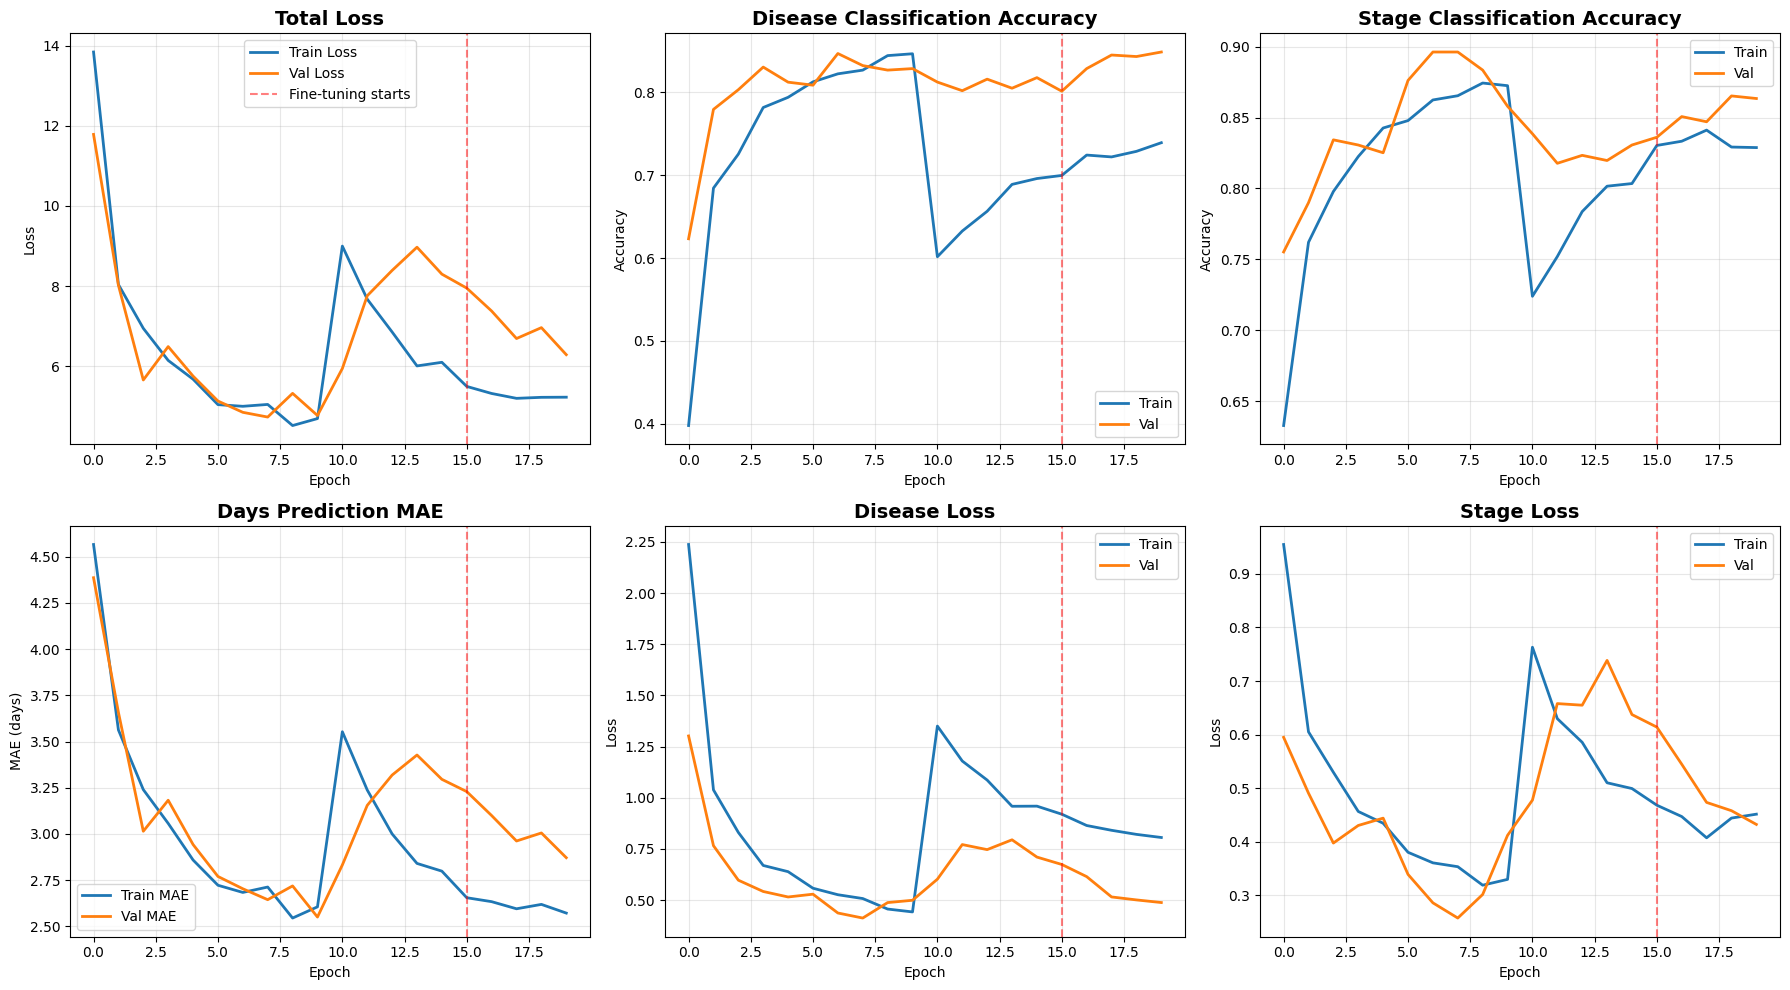

In [ ]:
def plot_training_history(history_phase1, history_phase2):
    """Plot comprehensive training history"""

    # Combine histories
    all_history = {}
    for key in history_phase1.history.keys():
        all_history[key] = history_phase1.history[key] + history_phase2.history[key]

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # Total Loss
    axes[0, 0].plot(all_history['loss'], label='Train Loss', linewidth=2)
    axes[0, 0].plot(all_history['val_loss'], label='Val Loss', linewidth=2)
    axes[0, 0].axvline(x=15, color='red', linestyle='--', alpha=0.5, label='Fine-tuning starts')
    axes[0, 0].set_title('Total Loss', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Disease Accuracy
    axes[0, 1].plot(all_history['disease_output_accuracy'], label='Train', linewidth=2)
    axes[0, 1].plot(all_history['val_disease_output_accuracy'], label='Val', linewidth=2)
    axes[0, 1].axvline(x=15, color='red', linestyle='--', alpha=0.5)
    axes[0, 1].set_title('Disease Classification Accuracy', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # Stage Accuracy
    axes[0, 2].plot(all_history['stage_output_accuracy'], label='Train', linewidth=2)
    axes[0, 2].plot(all_history['val_stage_output_accuracy'], label='Val', linewidth=2)
    axes[0, 2].axvline(x=15, color='red', linestyle='--', alpha=0.5)
    axes[0, 2].set_title('Stage Classification Accuracy', fontsize=14, fontweight='bold')
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('Accuracy')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)

    # Days MAE
    axes[1, 0].plot(all_history['days_output_mae'], label='Train MAE', linewidth=2)
    axes[1, 0].plot(all_history['val_days_output_mae'], label='Val MAE', linewidth=2)
    axes[1, 0].axvline(x=15, color='red', linestyle='--', alpha=0.5)
    axes[1, 0].set_title('Days Prediction MAE', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('MAE (days)')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # Disease Loss
    axes[1, 1].plot(all_history['disease_output_loss'], label='Train', linewidth=2)
    axes[1, 1].plot(all_history['val_disease_output_loss'], label='Val', linewidth=2)
    axes[1, 1].axvline(x=15, color='red', linestyle='--', alpha=0.5)
    axes[1, 1].set_title('Disease Loss', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Loss')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    # Stage Loss
    axes[1, 2].plot(all_history['stage_output_loss'], label='Train', linewidth=2)
    axes[1, 2].plot(all_history['val_stage_output_loss'], label='Val', linewidth=2)
    axes[1, 2].axvline(x=15, color='red', linestyle='--', alpha=0.5)
    axes[1, 2].set_title('Stage Loss', fontsize=14, fontweight='bold')
    axes[1, 2].set_xlabel('Epoch')
    axes[1, 2].set_ylabel('Loss')
    axes[1, 2].legend()
    axes[1, 2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('outputs/training_history.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_training_history(history_phase1, history_phase2)

In [ ]:
#P3
def compute_urgency_score(stage, days_since_infection, disease_name):
    """
    Compute actionable urgency score (0-10)
    """
    # Base urgency from stage
    stage_urgency = stage * 2.5

    # Speed factors
    speed_factors = {
        'late_blight': 1.5,
        'bacterial': 1.4,
        'black_rot': 1.3,
        'early_blight': 1.0,
        'leaf_spot': 1.0,
        'septoria': 1.0,
        'cercospora': 1.0,
        'rust': 0.7,
        'scab': 0.8,
        'powdery_mildew': 0.7,
        'mosaic': 0.8,
        'esca': 0.7,
        'haunglongbing': 0.6,
    }

    speed = 1.0
    disease_lower = disease_name.lower()
    for key, factor in speed_factors.items():
        if key in disease_lower:
            speed = factor
            break

    # Time-based urgency
    time_urgency = speed * (1 / max(days_since_infection, 1)) * 3

    # Combined urgency
    urgency = min(stage_urgency + time_urgency, 10.0)

    return round(urgency, 1)

def get_action_recommendation(urgency_score, stage):
    """Provide actionable recommendations"""
    if urgency_score >= 8:
        return {
            'priority': 'CRITICAL',
            'action': 'Immediate treatment required',
            'timeframe': 'Within 24 hours',
            'color': 'red',
            'icon': '🔴'
        }
    elif urgency_score >= 6:
        return {
            'priority': 'HIGH',
            'action': 'Treatment recommended soon',
            'timeframe': 'Within 48-72 hours',
            'color': 'orange',
            'icon': '🟠'
        }
    elif urgency_score >= 4:
        return {
            'priority': 'MODERATE',
            'action': 'Monitor closely and prepare treatment',
            'timeframe': 'Within 5-7 days',
            'color': 'yellow',
            'icon': '🟡'
        }
    elif urgency_score >= 2:
        return {
            'priority': 'LOW',
            'action': 'Continue monitoring',
            'timeframe': 'Check again in 1-2 weeks',
            'color': 'green',
            'icon': '🟢'
        }
    else:
        return {
            'priority': 'HEALTHY',
            'action': 'No action needed',
            'timeframe': 'Regular monitoring',
            'color': 'blue',
            'icon': '🔵'
        }

print("Urgency scoring functions created!")

Urgency scoring functions created!


In [ ]:
def predict_with_progression(model, image_path, class_names, stage_mapping):
    """Complete prediction with progression analysis"""

    # Load and preprocess image
    img = keras.preprocessing.image.load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = keras.preprocessing.image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Make prediction
    disease_pred, stage_pred, days_pred = model.predict(img_array, verbose=0)

    # Get disease prediction
    disease_idx = np.argmax(disease_pred[0])
    disease_conf = disease_pred[0][disease_idx]
    disease_name = class_names[disease_idx]

    # Get stage prediction
    stage_idx = np.argmax(stage_pred[0])
    stage_conf = stage_pred[0][stage_idx]

    # Get days prediction
    days_estimated = max(0, days_pred[0][0])

    # Calculate urgency
    urgency = compute_urgency_score(stage_idx, days_estimated, disease_name)
    recommendation = get_action_recommendation(urgency, stage_idx)

    # Compile results
    results = {
        'disease': {
            'name': disease_name,
            'confidence': float(disease_conf),
            'percentage': f'{disease_conf * 100:.2f}%'
        },
        'progression': {
            'stage': int(stage_idx),
            'stage_name': ['Healthy', 'Early', 'Mid-stage', 'Late-stage'][stage_idx],
            'confidence': float(stage_conf),
            'days_since_infection': round(float(days_estimated), 1)
        },
        'urgency': {
            'score': urgency,
            'priority': recommendation['priority'],
            'action': recommendation['action'],
            'timeframe': recommendation['timeframe'],
            'color': recommendation['color'],
            'icon': recommendation['icon']
        }
    }

    return results

print("Prediction function created!")

Prediction function created!


In [ ]:
def track_disease_progression(model, image_paths, timestamps, class_names, stage_mapping):
    """Track disease progression across multiple images"""

    progression_data = []

    for img_path, timestamp in zip(image_paths, timestamps):
        results = predict_with_progression(model, img_path, class_names, stage_mapping)

        progression_data.append({
            'timestamp': timestamp,
            'stage': results['progression']['stage'],
            'stage_name': results['progression']['stage_name'],
            'days_estimated': results['progression']['days_since_infection'],
            'urgency': results['urgency']['score'],
            'disease': results['disease']['name'],
            'confidence': results['disease']['confidence']
        })

    return progression_data

def plot_progression_curve(progression_data):
    """Visualize disease progression over time"""

    df = pd.DataFrame(progression_data)
    df['timestamp'] = pd.to_datetime(df['timestamp'])

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

    # Stage progression
    ax1.plot(df['timestamp'], df['stage'], marker='o', linewidth=3,
             markersize=10, color='#d32f2f', label='Disease Stage')
    ax1.fill_between(df['timestamp'], df['stage'], alpha=0.3, color='#d32f2f')
    ax1.set_ylabel('Disease Stage', fontsize=13, fontweight='bold')
    ax1.set_title('Disease Stage Progression Over Time', fontsize=15, fontweight='bold')
    ax1.set_yticks([0, 1, 2, 3])
    ax1.set_yticklabels(['Healthy', 'Early', 'Mid', 'Late'])
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(-0.2, 3.5)
    ax1.legend()

    # Urgency score progression
    ax2.plot(df['timestamp'], df['urgency'], marker='s', linewidth=3,
             markersize=10, color='#ff9800', label='Urgency Score')
    ax2.fill_between(df['timestamp'], df['urgency'], alpha=0.3, color='#ff9800')
    ax2.set_xlabel('Date', fontsize=13, fontweight='bold')
    ax2.set_ylabel('Urgency Score', fontsize=13, fontweight='bold')
    ax2.set_title('Treatment Urgency Over Time', fontsize=15, fontweight='bold')
    ax2.set_ylim(0, 10)
    ax2.grid(True, alpha=0.3)

    # Add urgency zones
    ax2.axhspan(0, 2, alpha=0.1, color='green', label='Low')
    ax2.axhspan(2, 4, alpha=0.1, color='yellow', label='Moderate')
    ax2.axhspan(4, 6, alpha=0.1, color='orange', label='High')
    ax2.axhspan(6, 10, alpha=0.1, color='red', label='Critical')
    ax2.legend(loc='upper left')

    plt.tight_layout()
    plt.savefig('outputs/progression_curve.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Calculate progression rate
    if len(df) > 1:
        days_elapsed = (df['timestamp'].iloc[-1] - df['timestamp'].iloc[0]).days
        stage_change = df['stage'].iloc[-1] - df['stage'].iloc[0]

        if days_elapsed > 0:
            progression_rate = stage_change / days_elapsed

            print(f"\nProgression Analysis:")
            print(f"{'─'*50}")
            print(f"Days monitored: {days_elapsed}")
            print(f"Stage change: {stage_change}")
            print(f"Progression rate: {progression_rate:.3f} stages/day")
            print(f"{'─'*50}")

            if progression_rate > 0.15:
                print(f"WARNING: Rapid disease progression detected!")
            elif progression_rate > 0.05:
                print(f"Moderate progression - monitor closely")
            else:
                print(f"Slow progression")

print("Temporal tracking functions created!")

Temporal tracking functions created!


In [ ]:
#P4
# Make predictions on test set
disease_preds, stage_preds, days_preds = progression_model.predict(test_images, verbose=1)

# Get predicted classes
disease_pred_classes = np.argmax(disease_preds, axis=1)
stage_pred_classes = np.argmax(stage_preds, axis=1)
days_pred_values = days_preds.flatten()

# Calculate metrics
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error, mean_squared_error

disease_acc = accuracy_score(test_labels, disease_pred_classes)
disease_f1 = f1_score(test_labels, disease_pred_classes, average='weighted')

stage_acc = accuracy_score(test_stage_labels, stage_pred_classes)
stage_f1 = f1_score(test_stage_labels, stage_pred_classes, average='weighted')

days_mae = mean_absolute_error(test_days_labels, days_pred_values)
days_rmse = np.sqrt(mean_squared_error(test_days_labels, days_pred_values))

print(f"\n{'='*70}")
print(f"TEST SET RESULTS")
print(f"{'='*70}")
print(f"\n Disease Classification:")
print(f"  Accuracy: {disease_acc*100:.2f}%")
print(f"  F1 Score: {disease_f1:.4f}")

print(f"\n Stage Classification:")
print(f"  Accuracy: {stage_acc*100:.2f}%")
print(f"  F1 Score: {stage_f1:.4f}")

print(f"\n Days Regression:")
print(f"  MAE: {days_mae:.2f} days")
print(f"  RMSE: {days_rmse:.2f} days")
print(f"{'='*70}\n")

# Store evaluation results
eval_results = {
    'disease_preds': disease_pred_classes,
    'disease_labels': test_labels,
    'stage_preds': stage_pred_classes,
    'stage_labels': test_stage_labels,
    'days_preds': days_pred_values,
    'days_labels': test_days_labels,
    'metrics': {
        'disease_acc': disease_acc,
        'disease_f1': disease_f1,
        'stage_acc': stage_acc,
        'stage_f1': stage_f1,
        'days_mae': days_mae,
        'days_rmse': days_rmse
    }
}

19/19 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step

TEST SET RESULTS

 Disease Classification:
  Accuracy: 80.24%
  F1 Score: 0.7993

 Stage Classification:
  Accuracy: 82.13%
  F1 Score: 0.8137

 Days Regression:
  MAE: 2.81 days
  RMSE: 4.21 days



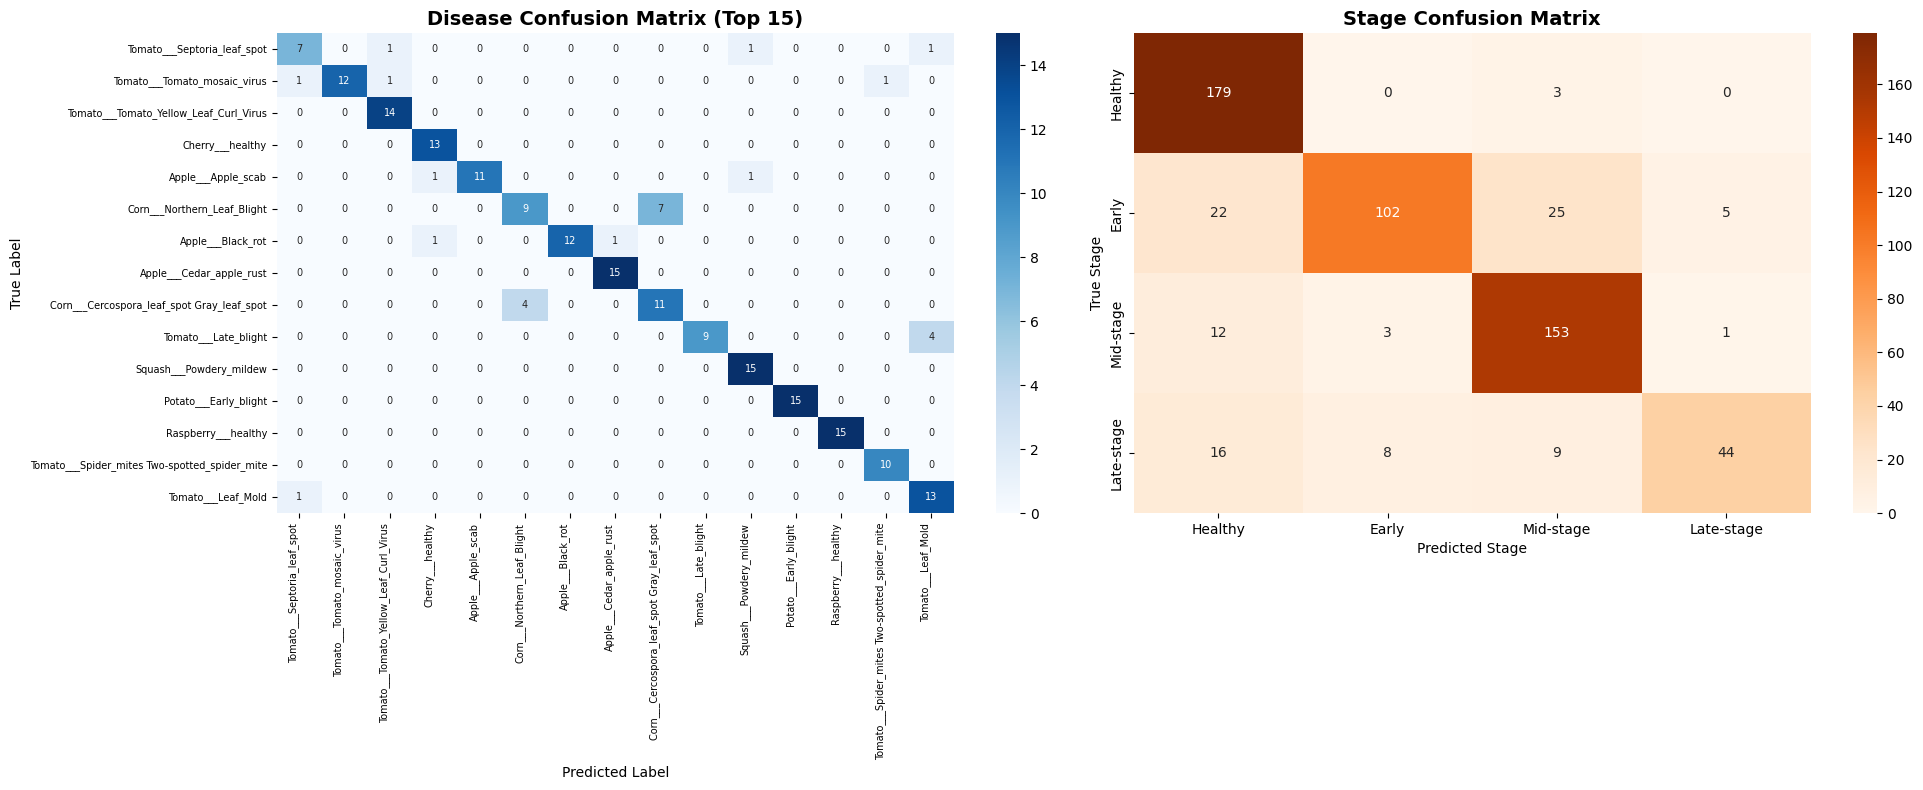

In [ ]:
def plot_confusion_matrices(eval_results, class_names):
    """Plot confusion matrices"""

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

    # Disease confusion matrix (top 15 classes)
    disease_cm = confusion_matrix(eval_results['disease_labels'], eval_results['disease_preds'])
    top_15_indices = np.argsort(np.sum(disease_cm, axis=1))[-15:]
    disease_cm_top15 = disease_cm[top_15_indices][:, top_15_indices]
    top_15_names = [class_names[i] for i in top_15_indices]

    sns.heatmap(disease_cm_top15, annot=True, fmt='d', cmap='Blues',
                xticklabels=top_15_names, yticklabels=top_15_names, ax=ax1, annot_kws={"size": 7})
    ax1.set_title('Disease Confusion Matrix (Top 15)', fontsize=14, fontweight='bold')
    ax1.set_ylabel('True Label')
    ax1.set_xlabel('Predicted Label')
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=90, ha='right', fontsize=7)
    plt.setp(ax1.yaxis.get_majorticklabels(), rotation=0, fontsize=7)

    # Stage confusion matrix
    stage_cm = confusion_matrix(eval_results['stage_labels'], eval_results['stage_preds'])
    stage_names = ['Healthy', 'Early', 'Mid-stage', 'Late-stage']

    sns.heatmap(stage_cm, annot=True, fmt='d', cmap='Oranges',
                xticklabels=stage_names, yticklabels=stage_names, ax=ax2)
    ax2.set_title('Stage Confusion Matrix', fontsize=14, fontweight='bold')
    ax2.set_ylabel('True Stage')
    ax2.set_xlabel('Predicted Stage')

    plt.tight_layout()
    plt.savefig('outputs/confusion_matrices.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_confusion_matrices(eval_results, class_names)

In [ ]:
def visualize_predictions(model, test_images, test_labels, class_names, stage_mapping, num_samples=9):
    """Visualize sample predictions"""

    indices = np.random.choice(len(test_images), num_samples, replace=False)

    fig, axes = plt.subplots(3, 3, figsize=(18, 18))
    axes = axes.ravel()

    for idx, i in enumerate(indices):
        image = test_images[i:i+1]
        true_label = test_labels[i]

        # Predict
        disease_pred, stage_pred, days_pred = model.predict(image, verbose=0)

        disease_idx = np.argmax(disease_pred[0])
        stage_idx = np.argmax(stage_pred[0])
        days_val = days_pred[0][0]

        # Get urgency
        urgency = compute_urgency_score(stage_idx, days_val, class_names[disease_idx])

        # Display
        axes[idx].imshow(image[0])

        stage_names = ['Healthy', 'Early', 'Mid', 'Late']
        title = f"Pred: {class_names[disease_idx][:25]}...\n"
        title += f"True: {class_names[true_label][:25]}...\n"
        title += f"Stage: {stage_names[stage_idx]} | Days: ~{days_val:.1f}\n"
        title += f"Urgency: {urgency}/10"

        color = 'red' if urgency >= 8 else 'orange' if urgency >= 6 else 'gold' if urgency >= 4 else 'green'

        axes[idx].set_title(title, fontsize=8, color=color, fontweight='bold')
        axes[idx].axis('off')

    plt.tight_layout()
    plt.savefig('outputs/sample_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_predictions(progression_model, test_images, test_labels, class_names, complete_stage_mapping)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# Save the final model
progression_model.save('models/final_progression_model.h5')
print("Model saved: models/final_progression_model.h5")

# Save metadata
metadata = {
    'class_names': class_names,
    'stage_mapping': complete_stage_mapping,
    'num_classes': num_classes,
    'img_size': IMG_SIZE,
    'model_architecture': 'MobileNetV2',
    'total_samples': len(limited_images),
    'train_samples': len(train_images),
    'val_samples': len(val_images),
    'test_samples': len(test_images),
    'disease_acc': float(disease_acc),
    'stage_acc': float(stage_acc),
    'days_mae': float(days_mae),
    'created_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}

with open('models/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Metadata saved: models/metadata.json")

Model saved: models/final_progression_model.h5
Metadata saved: models/metadata.json


In [ ]:
#P5
